In [2]:
pip install pykrige

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 28.8 MB/s eta 0:00:00


  Well_Name  X_Coordinate (m)  Y_Coordinate (m)  \
0    Well_1       2185.430535       3389.142408   
1    Well_2       4778.214379        878.629842   
2    Well_3       3793.972738       1227.329213   
3    Well_4       3193.963179       4543.493848   
4    Well_5       1202.083882       3228.930768   

   Normalized_Cumulative_Oil_Production (MMm3)  \
0                                     0.964057   
1                                     4.561488   
2                                     2.773636   
3                                     4.219059   
4                                     1.940223   

   Cumulative_Oil_Production_on_3M (MMm3)  Porosity (fraction)  \
0                                1.260208             0.256316   
1                                1.753657             0.078812   
2                                1.296547             0.214412   
3                                0.899161             0.224149   
4                                1.042861             0.165722

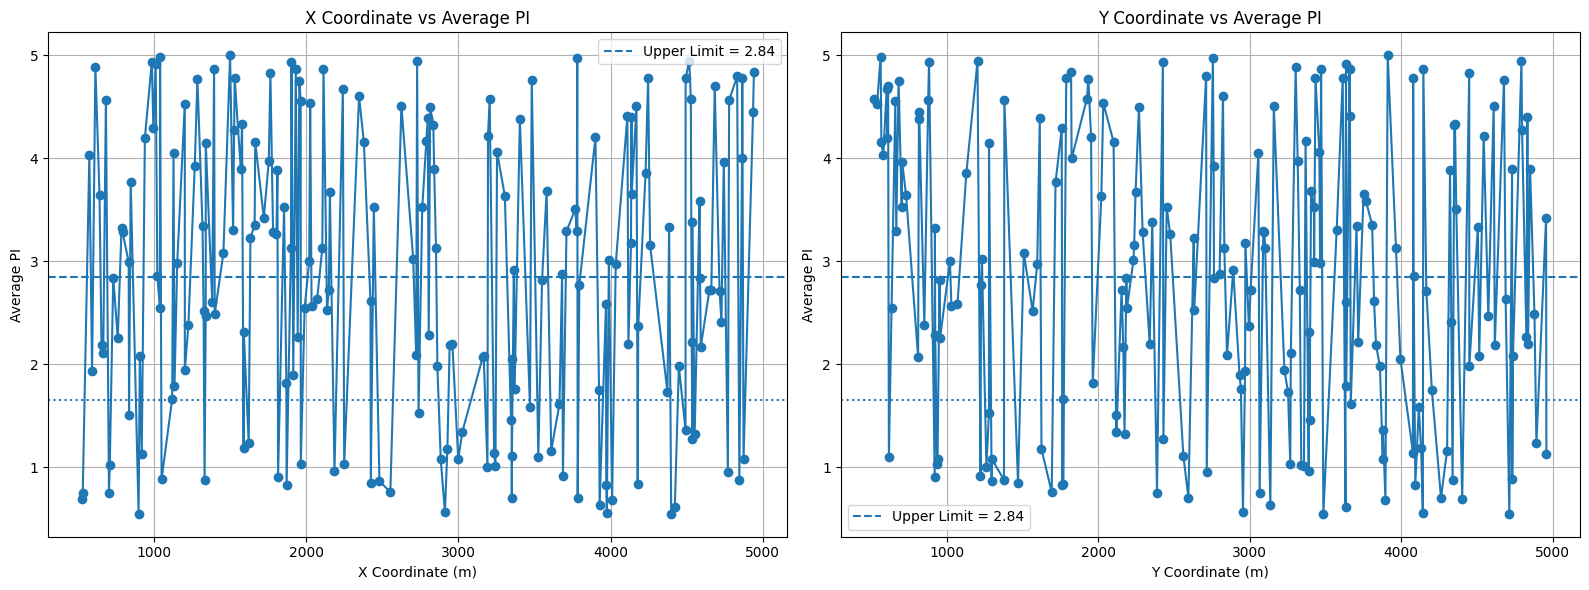

X crossings: [np.float64(558.9662197411485), np.float64(584.8310945072017), np.float64(599.3175461179051), np.float64(648.7289213602104), np.float64(671.199026984313), np.float64(692.5498364946469), np.float64(774.9650000134169), np.float64(833.4297023473611), np.float64(841.945536995816), np.float64(861.279827408339), np.float64(930.4575554669503), np.float64(1022.0135473648926), np.float64(1038.3207342399405), np.float64(1044.4982714494397), np.float64(1123.2288685033432), np.float64(1131.1577440422348), np.float64(1149.930386669408), np.float64(1202.0460423139832), np.float64(1237.9874825133338), np.float64(1322.5208916998954), np.float64(1339.3850265612145), np.float64(1375.479015895284), np.float64(1383.1990296961415), np.float64(1397.8861991434367), np.float64(1432.7274779491684), np.float64(1582.9076994801462), np.float64(1630.8603554080648), np.float64(1811.974880956983), np.float64(1843.727286890331), np.float64(1859.9927530954221), np.float64(1895.8550773485133), np.float64(1

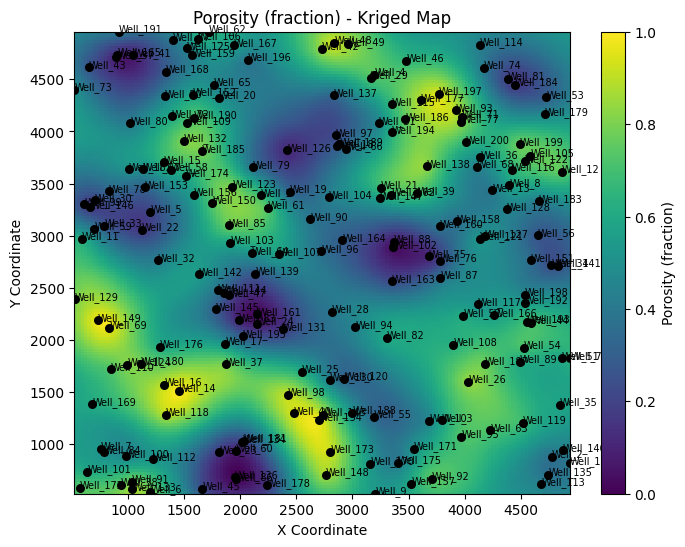

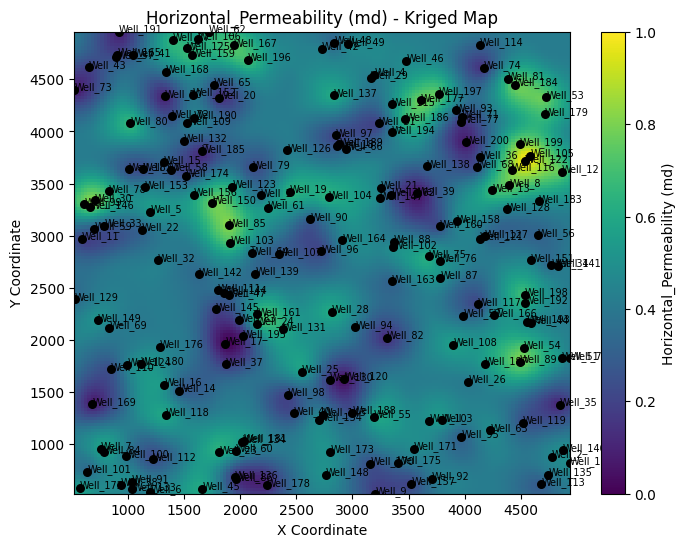

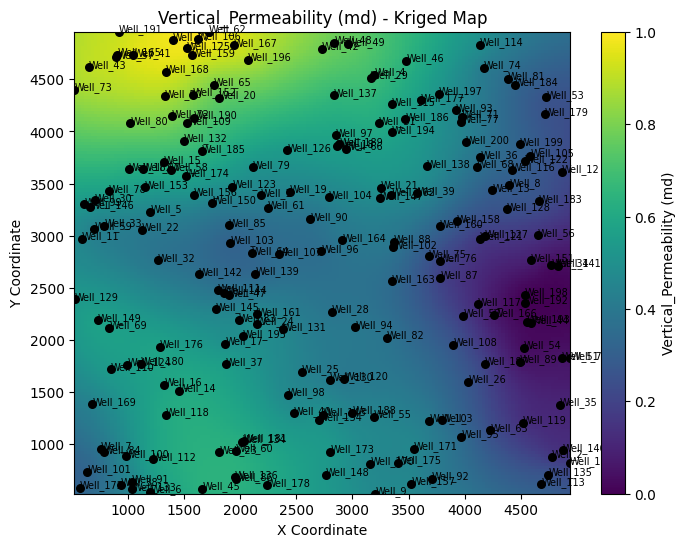

      Sector  Phi_avg_krig  Phi_I  Kh_avg_krig  Kh_I  HI
0      S_0_0      0.189770      2     0.217438     2   2
1     S_0_11      0.180124      2     0.213392     2   2
2     S_0_12      0.180445      2     0.211190     2   2
3     S_0_15      0.181132      2     0.207664     2   2
4     S_0_17      0.181780      2     0.205912     2   2
...      ...           ...    ...          ...   ...  ..
5619  S_9_93      0.157584      2     0.204810     2   2
5620  S_9_94      0.160263      2     0.203805     2   2
5621  S_9_97      0.163403      2     0.203017     2   2
5622  S_9_98      0.165659      2     0.202562     2   2
5623  S_9_99      0.169039      2     0.202088     2   2

[5624 rows x 6 columns]


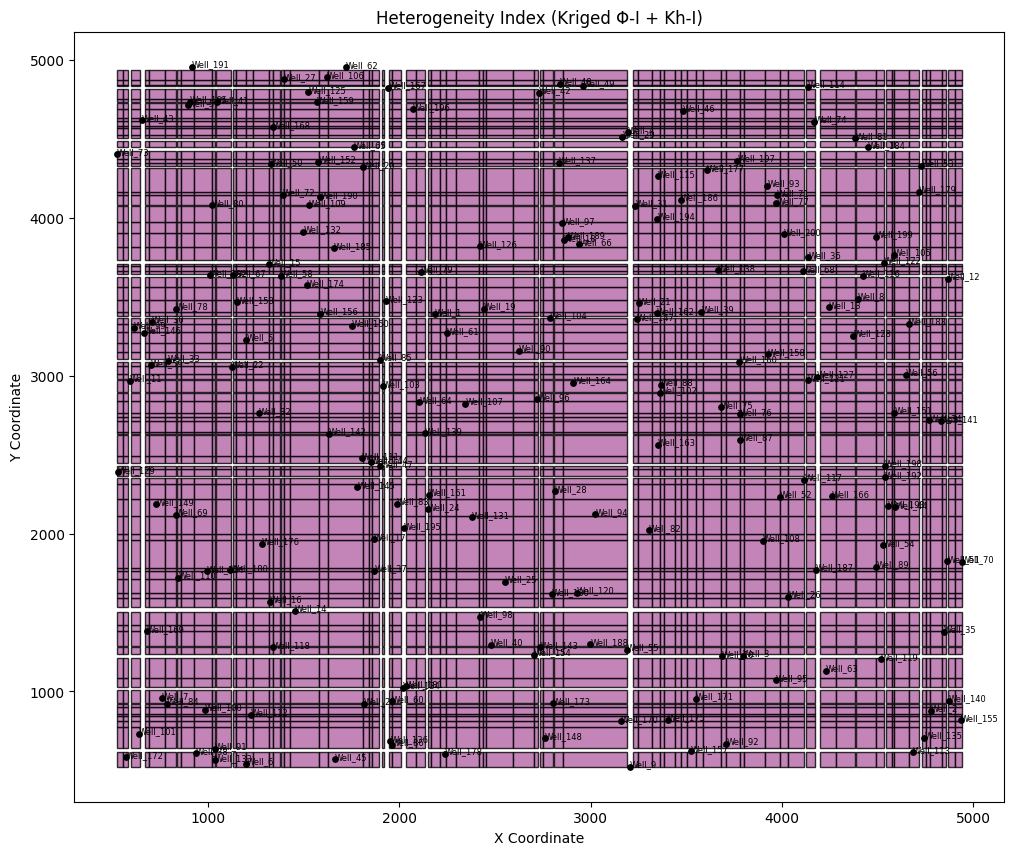

      Sector  Sector_WPI  HI  Hybrid_Score                Category
0     S_0_33           2   2             4      Moderate Potential
1     S_0_81           2   2             4      Moderate Potential
2    S_10_91           2   2             4      Moderate Potential
3    S_10_93           1   2             3  Near Maximum Potential
4     S_11_0           1   2             3  Near Maximum Potential
..       ...         ...  ..           ...                     ...
132  S_96_17           2   2             4      Moderate Potential
133   S_98_9           2   2             4      Moderate Potential
134  S_99_26           1   2             3  Near Maximum Potential
135   S_99_4           1   2             3  Near Maximum Potential
136   S_9_24           1   2             3  Near Maximum Potential

[137 rows x 5 columns]


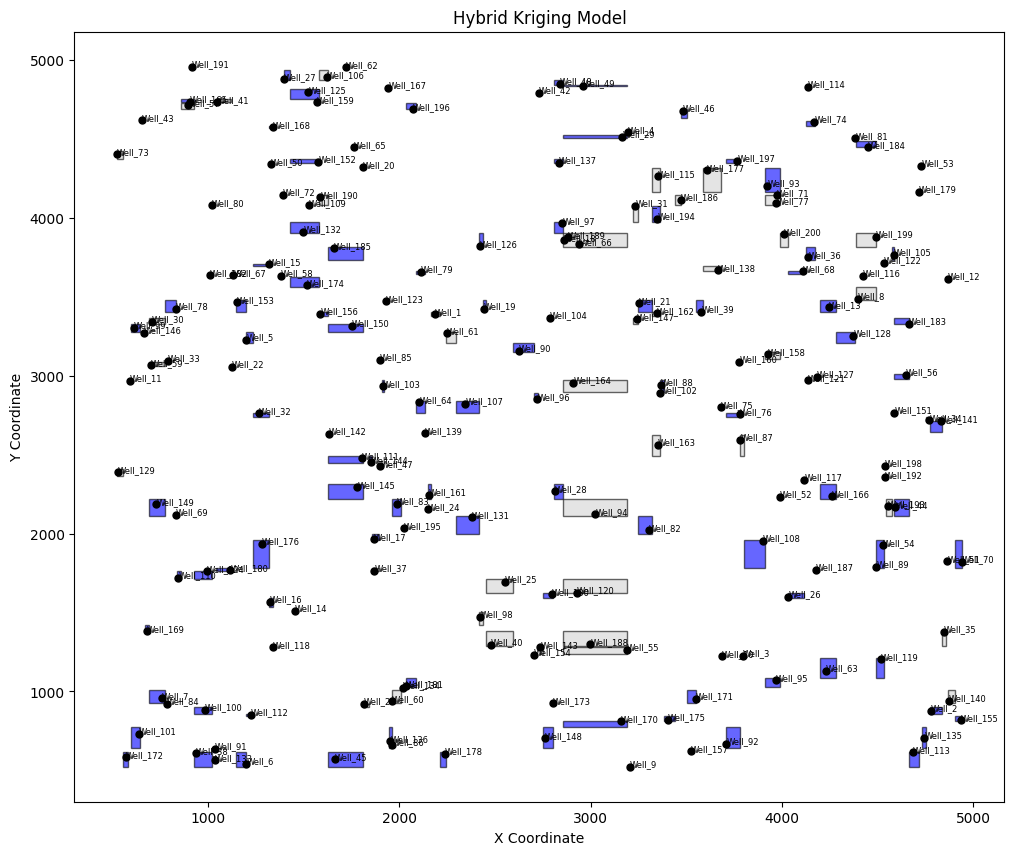

In [3]:



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pykrige.ok import OrdinaryKriging

np.random.seed(42)

# =====================================================
# STEP 0: Generate dummy well dataset
# =====================================================

n_wells = 200

data = {
    "Well_Name": [f"Well_{i+1}" for i in range(n_wells)],
    "X_Coordinate (m)": np.random.uniform(500, 5000, n_wells),
    "Y_Coordinate (m)": np.random.uniform(500, 5000, n_wells),
    "Normalized_Cumulative_Oil_Production (MMm3)": np.random.uniform(0.5, 5.0, n_wells),
    "Cumulative_Oil_Production_on_3M (MMm3)": np.random.uniform(0.5, 5.0, n_wells),
    "Porosity (fraction)": np.random.uniform(0.03, 0.35, n_wells),
    "Horizontal_Permeability (md)": np.random.uniform(0.05, 0.35, n_wells),
    "Vertical_Permeability (md)": np.random.uniform(5, 1500, n_wells),
    "Net_Thickness (m)": np.random.uniform(10, 180, n_wells),
    "Desired_Horizontal_Well_Length (m)": np.random.uniform(5, 50, n_wells),
    "Average_Oil_Flow_Rate_3Y (m3/day)": np.random.uniform(500, 2000, n_wells),
    "Average_Oil_Flow_Rate_3M (m3/day)": np.random.uniform(500, 4500, n_wells),
    "Average_Water_Flow_Rate_3Y (m3/day)": np.random.uniform(300, 4000, n_wells),
    "Average_Water_Flow_Rate_3M (m3/day)": np.random.uniform(50, 800, n_wells),
    "WOR_3Y": np.random.uniform(20, 500, n_wells),
    "WOR_3M": np.random.uniform(0.05, 0.20, n_wells),
}

df = pd.DataFrame(data)
df.to_csv("dummy_well_dataset.csv", index=False)


PI = "Normalized_Cumulative_Oil_Production (MMm3)"

print(df.head())
print("\nDataset Shape:", df.shape)


# =====================================================
# STEP 1: X / Y trend profiles and threshold crossings
# =====================================================

x_df = (
    df.groupby("X_Coordinate (m)")[PI]
      .mean()
      .reset_index(name="Average_PI")
      .sort_values("X_Coordinate (m)")
)
y_df = (
    df.groupby("Y_Coordinate (m)")[PI]
      .mean()
      .reset_index(name="Average_PI")
      .sort_values("Y_Coordinate (m)")
)

upper_limit_x = x_df["Average_PI"].mean()
lower_limit_x = x_df["Average_PI"].quantile(0.25)

upper_limit_y = y_df["Average_PI"].mean()
lower_limit_y = y_df["Average_PI"].quantile(0.25)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(x_df["X_Coordinate (m)"], x_df["Average_PI"], marker='o')
axes[0].axhline(upper_limit_x, linestyle='--', label=f'Upper Limit = {upper_limit_x:.2f}')
axes[0].axhline(lower_limit_x, linestyle=':')
axes[0].set_title("X Coordinate vs Average PI")
axes[0].set_xlabel("X Coordinate (m)")
axes[0].set_ylabel("Average PI")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(y_df["Y_Coordinate (m)"], y_df["Average_PI"], marker='o')
axes[1].axhline(upper_limit_y, linestyle='--', label=f'Upper Limit = {upper_limit_y:.2f}')
axes[1].axhline(lower_limit_y, linestyle=':')
axes[1].set_title("Y Coordinate vs Average PI")
axes[1].set_xlabel("Y Coordinate (m)")
axes[1].set_ylabel("Average PI")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()


def find_crossings(coord_vals, pi_vals, threshold):
    """Detect threshold crossings via sign-change test + linear interpolation."""
    crossings = []
    for i in range(len(coord_vals) - 1):
        d1 = pi_vals[i] - threshold
        d2 = pi_vals[i + 1] - threshold
        if d1 * d2 < 0:
            xc = coord_vals[i] + (coord_vals[i + 1] - coord_vals[i]) * (
                (threshold - pi_vals[i]) / (pi_vals[i + 1] - pi_vals[i])
            )
            crossings.append(xc)
    return crossings


x_crossings = sorted(find_crossings(
    x_df["X_Coordinate (m)"].values, x_df["Average_PI"].values, upper_limit_x
))
y_crossings = sorted(find_crossings(
    y_df["Y_Coordinate (m)"].values, y_df["Average_PI"].values, upper_limit_y
))

print("X crossings:", x_crossings)
print("Y crossings:", y_crossings)


# =====================================================
# STEP 2: Assign well-level PIX / PIY / WPI
# =====================================================

def assign_rank(pi, upper, lower):
    if pi >= upper:
        return 1
    elif pi < lower:
        return 3
    else:
        return 2


x_df["PIX"] = x_df["Average_PI"].apply(lambda pi: assign_rank(pi, upper_limit_x, lower_limit_x))
y_df["PIY"] = y_df["Average_PI"].apply(lambda pi: assign_rank(pi, upper_limit_y, lower_limit_y))

df["PIX"] = df["X_Coordinate (m)"].map(x_df.set_index("X_Coordinate (m)")["PIX"])
df["PIY"] = df["Y_Coordinate (m)"].map(y_df.set_index("Y_Coordinate (m)")["PIY"])

df["Rank_Sum"] = df["PIX"] + df["PIY"]


def assign_wpi(rank_sum):
    if rank_sum <= 3:
        return 1
    elif rank_sum <= 5:
        return 2
    else:
        return 3


df["WPI"] = df["Rank_Sum"].apply(assign_wpi)


# =====================================================
# STEP 3: Build sector grid and aggregate sector-level WPI
# =====================================================

df["sector_x"] = np.digitize(df["X_Coordinate (m)"], x_crossings)
df["sector_y"] = np.digitize(df["Y_Coordinate (m)"], y_crossings)
df["Sector"] = "S_" + df["sector_x"].astype(str) + "_" + df["sector_y"].astype(str)

sector_stats = (
    df.groupby("Sector")
      .agg(well_count=("WPI", "count"), wpi_sum=("WPI", "sum"))
      .reset_index()
)


def assign_sector_wpi(row):
    wc = row["well_count"]
    ws = row["wpi_sum"]
    if wc <= ws <= wc + 1:
        return 1
    elif wc + 1 < ws <= (2 * wc + 1):
        return 2
    elif (2 * wc + 1) < ws <= (3 * wc):
        return 3
    else:
        return np.nan


sector_stats["Sector_WPI"] = sector_stats.apply(assign_sector_wpi, axis=1)

df = df.merge(sector_stats[["Sector", "Sector_WPI"]], on="Sector", how="left")


# =====================================================
# STEP 4: Ordinary kriging - porosity & horizontal permeability
# =====================================================

def krige_property(source_df, property_col, grid_res=150):
    """Runs ordinary kriging and returns grid coordinates + interpolated surface."""
    x = source_df["X_Coordinate (m)"].values
    y = source_df["Y_Coordinate (m)"].values
    z = source_df[property_col].values

    gridx = np.linspace(x.min(), x.max(), grid_res)
    gridy = np.linspace(y.min(), y.max(), grid_res)

    OK = OrdinaryKriging(x, y, z, variogram_model="spherical")
    zgrid, ss = OK.execute("grid", gridx, gridy)

    return gridx, gridy, zgrid, ss


def plot_kriged_map(source_df, property_col, gridx, gridy, zgrid):
    plt.figure(figsize=(8, 6))
    plt.imshow(
        zgrid,
        extent=[gridx.min(), gridx.max(), gridy.min(), gridy.max()],
        origin="lower",
        aspect="auto"
    )
    plt.scatter(source_df["X_Coordinate (m)"], source_df["Y_Coordinate (m)"], c="black", s=30)
    for _, row in source_df.iterrows():
        plt.text(row["X_Coordinate (m)"], row["Y_Coordinate (m)"], row["Well_Name"], fontsize=7)
    plt.colorbar(label=property_col)
    plt.title(f"{property_col} - Kriged Map")
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.show()


gridx, gridy, phi_grid, phi_ss = krige_property(df, "Porosity (fraction)")
_, _, kh_grid, kh_ss = krige_property(df, "Horizontal_Permeability (md)")
_, _, kv_grid, kv_ss = krige_property(df, "Vertical_Permeability (md)")

plot_kriged_map(df, "Porosity (fraction)", gridx, gridy, phi_grid)
plot_kriged_map(df, "Horizontal_Permeability (md)", gridx, gridy, kh_grid)
plot_kriged_map(df, "Vertical_Permeability (md)", gridx, gridy, kv_grid)


# =====================================================
# STEP 5: Sector-level Phi_I / Kh_I / HI - FROM THE KRIGED SURFACE
# =====================================================

x_bounds = [df["X_Coordinate (m)"].min(), *x_crossings, df["X_Coordinate (m)"].max()]
y_bounds = [df["Y_Coordinate (m)"].min(), *y_crossings, df["Y_Coordinate (m)"].max()]


def sector_avg_from_kriged(gridx, gridy, zgrid, x_bounds, y_bounds):
    """Averages kriged grid points that fall inside each sector's bounds."""
    records = []
    for i in range(len(x_bounds) - 1):
        x_lo, x_hi = x_bounds[i], x_bounds[i + 1]
        x_mask = (gridx >= x_lo) & (gridx < x_hi)

        for j in range(len(y_bounds) - 1):
            y_lo, y_hi = y_bounds[j], y_bounds[j + 1]
            y_mask = (gridy >= y_lo) & (gridy < y_hi)

            if not x_mask.any() or not y_mask.any():
                continue

            cell_values = zgrid[np.ix_(y_mask, x_mask)]
            records.append({"Sector": f"S_{i}_{j}", "Kriged_avg": np.nanmean(cell_values)})

    return pd.DataFrame(records)


phi_sector_krig = sector_avg_from_kriged(gridx, gridy, phi_grid, x_bounds, y_bounds)
phi_sector_krig = phi_sector_krig.rename(columns={"Kriged_avg": "Phi_avg_krig"})

kh_sector_krig = sector_avg_from_kriged(gridx, gridy, kh_grid, x_bounds, y_bounds)
kh_sector_krig = kh_sector_krig.rename(columns={"Kriged_avg": "Kh_avg_krig"})

sector_props = phi_sector_krig.merge(kh_sector_krig, on="Sector", how="outer")

# Thresholds: 75th/25th percentile of well-level data, per reference methodology
phi_upper = df["Porosity (fraction)"].quantile(0.75)
phi_lower = df["Porosity (fraction)"].quantile(0.25)

kh_upper = df["Horizontal_Permeability (md)"].quantile(0.75)
kh_lower = df["Horizontal_Permeability (md)"].quantile(0.25)


def phi_index(phi):
    if phi >= phi_upper:
        return 1
    elif phi <= phi_lower:
        return 3
    else:
        return 2


def kh_index(kh):
    if kh >= kh_upper:
        return 1
    elif kh <= kh_lower:
        return 3
    else:
        return 2


sector_props["Phi_I"] = sector_props["Phi_avg_krig"].apply(phi_index)
sector_props["Kh_I"] = sector_props["Kh_avg_krig"].apply(kh_index)

sector_props["HI_Sum"] = sector_props["Phi_I"] + sector_props["Kh_I"]


def assign_hi(rank_sum):
    if rank_sum <= 3:
        return 1
    elif rank_sum <= 5:
        return 2
    else:
        return 3


sector_props["HI"] = sector_props["HI_Sum"].apply(assign_hi)

print(sector_props[["Sector", "Phi_avg_krig", "Phi_I", "Kh_avg_krig", "Kh_I", "HI"]])


# =====================================================
# STEP 6: Heterogeneity Index map
# =====================================================

fig, ax = plt.subplots(figsize=(12, 10))

sector_lookup = sector_props.set_index("Sector")["HI"].to_dict()

for i in range(len(x_bounds) - 1):
    for j in range(len(y_bounds) - 1):
        sector_name = f"S_{i}_{j}"
        if sector_name not in sector_lookup:
            continue

        hi = sector_lookup[sector_name]
        color = {1: "#4b2e83", 2: "#b565a7", 3: "#ff4f88"}[hi]

        rect = Rectangle(
            (x_bounds[i], y_bounds[j]),
            x_bounds[i + 1] - x_bounds[i],
            y_bounds[j + 1] - y_bounds[j],
            facecolor=color,
            alpha=0.8,
            edgecolor="black"
        )
        ax.add_patch(rect)

ax.scatter(df["X_Coordinate (m)"], df["Y_Coordinate (m)"], color="black", s=15)
for _, row in df.iterrows():
    ax.text(row["X_Coordinate (m)"], row["Y_Coordinate (m)"], row["Well_Name"], fontsize=6)

ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")
ax.set_title("Heterogeneity Index (Kriged Φ-I + Kh-I)")
plt.show()


# =====================================================
# STEP 7: Hybrid Score and Sweet Spot Classification
# =====================================================

sector_hybrid = sector_stats.merge(sector_props[["Sector", "HI"]], on="Sector", how="inner")
sector_hybrid["Hybrid_Score"] = sector_hybrid["Sector_WPI"] + sector_hybrid["HI"]


def classify_sector(row):
    wpi = row["Sector_WPI"]
    hi = row["HI"]

    if wpi == 1 and hi == 1:
        return "Sweet Spot"
    elif hi == 1 and wpi > 1:
        return "Intervention Candidate"
    elif wpi == 1 and hi > 1:
        return "Near Maximum Potential"
    elif wpi == 3 and hi == 3:
        return "Low Priority"
    else:
        return "Moderate Potential"


sector_hybrid["Category"] = sector_hybrid.apply(classify_sector, axis=1)

print(sector_hybrid[["Sector", "Sector_WPI", "HI", "Hybrid_Score", "Category"]])


# =====================================================
# STEP 8: Hybrid Kriging Model map
# =====================================================

fig, ax = plt.subplots(figsize=(12, 10))

hybrid_lookup = sector_hybrid.set_index("Sector")["Category"].to_dict()
category_colors = {
    "Sweet Spot": "green",
    "Intervention Candidate": "orange",
    "Near Maximum Potential": "blue",
    "Low Priority": "red",
    "Moderate Potential": "lightgray",
}

for i in range(len(x_bounds) - 1):
    for j in range(len(y_bounds) - 1):
        sector_name = f"S_{i}_{j}"
        if sector_name not in hybrid_lookup:
            continue

        category = hybrid_lookup[sector_name]
        color = category_colors[category]

        rect = Rectangle(
            (x_bounds[i], y_bounds[j]),
            x_bounds[i + 1] - x_bounds[i],
            y_bounds[j + 1] - y_bounds[j],
            facecolor=color,
            alpha=0.6,
            edgecolor="black"
        )
        ax.add_patch(rect)

ax.scatter(df["X_Coordinate (m)"], df["Y_Coordinate (m)"], color="black", s=25)
for _, row in df.iterrows():
    ax.text(row["X_Coordinate (m)"], row["Y_Coordinate (m)"], row["Well_Name"], fontsize=6)

ax.set_title("Hybrid Kriging Model")
ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")
plt.show()

In [4]:
def rank_by_quantile(series, higher_is_worse=True):
    """
    Buckets a series into 1 (best) / 2 (moderate) / 3 (worst) using
    75th/25th percentile thresholds - same pattern used everywhere
    else in this pipeline (Phi_I, Kh_I, PIX, PIY).
    """
    upper = series.quantile(0.75)
    lower = series.quantile(0.25)

    def _rank(v):
        if higher_is_worse:
            if v >= upper:
                return 3
            elif v <= lower:
                return 1
            else:
                return 2
        else:
            if v >= upper:
                return 1
            elif v <= lower:
                return 3
            else:
                return 2

    return series.apply(_rank)


# --- Water-Oil Ratio trend: higher WOR = worse (more water, less oil) ---
df["WOR_WPI_3Y"] = rank_by_quantile(df["WOR_3Y"], higher_is_worse=True)
df["WOR_WPI_3M"] = rank_by_quantile(df["WOR_3M"], higher_is_worse=True)

# --- Oil flow rate trend: higher flow rate = better ---
df["OilRate_WPI_3Y"] = rank_by_quantile(df["Average_Oil_Flow_Rate_3Y (m3/day)"], higher_is_worse=False)
df["OilRate_WPI_3M"] = rank_by_quantile(df["Average_Oil_Flow_Rate_3M (m3/day)"], higher_is_worse=False)


def classify_water_trend(row):
    if row["WOR_WPI_3M"] > row["WOR_WPI_3Y"]:
        return "Water Shut-off Candidate"
    elif row["WOR_WPI_3M"] < row["WOR_WPI_3Y"]:
        return "Improved (past intervention effective)"
    else:
        return "Stable"


def classify_production_trend(row):
    if row["OilRate_WPI_3M"] > row["OilRate_WPI_3Y"]:
        return "Declining Production"
    elif row["OilRate_WPI_3M"] < row["OilRate_WPI_3Y"]:
        return "Improved Production"
    else:
        return "Stable"


df["Water_Trend"] = df.apply(classify_water_trend, axis=1)
df["Production_Trend"] = df.apply(classify_production_trend, axis=1)

# --- Extract well name lists for direct reporting ---
water_shutoff_wells = df.loc[df["Water_Trend"] == "Water Shut-off Candidate", "Well_Name"].tolist()
declining_wells = df.loc[df["Production_Trend"] == "Declining Production", "Well_Name"].tolist()

# Wells hit by BOTH issues at once - highest-priority intervention candidates
urgent_wells = sorted(set(water_shutoff_wells) & set(declining_wells))

print(f"\nWells flagged for Water Shut-off ({len(water_shutoff_wells)}):")
print(water_shutoff_wells)

print(f"\nWells with Declining Production ({len(declining_wells)}):")
print(declining_wells)

print(f"\nWells needing URGENT attention (both water shut-off AND declining production) ({len(urgent_wells)}):")
print(urgent_wells)

# Full reference table, in case you want to inspect individual wells
trend_summary = df[[
    "Well_Name", "WOR_3Y", "WOR_3M", "WOR_WPI_3Y", "WOR_WPI_3M", "Water_Trend",
    "Average_Oil_Flow_Rate_3Y (m3/day)", "Average_Oil_Flow_Rate_3M (m3/day)",
    "OilRate_WPI_3Y", "OilRate_WPI_3M", "Production_Trend"
]]
print("\nFull well-level trend summary:")
print(trend_summary.head(10))


Wells flagged for Water Shut-off (59):
['Well_1', 'Well_2', 'Well_4', 'Well_5', 'Well_6', 'Well_7', 'Well_10', 'Well_12', 'Well_16', 'Well_27', 'Well_34', 'Well_36', 'Well_42', 'Well_44', 'Well_45', 'Well_51', 'Well_54', 'Well_61', 'Well_63', 'Well_67', 'Well_71', 'Well_72', 'Well_73', 'Well_74', 'Well_79', 'Well_86', 'Well_87', 'Well_89', 'Well_90', 'Well_93', 'Well_96', 'Well_104', 'Well_107', 'Well_109', 'Well_114', 'Well_120', 'Well_126', 'Well_127', 'Well_128', 'Well_142', 'Well_143', 'Well_144', 'Well_148', 'Well_150', 'Well_151', 'Well_160', 'Well_162', 'Well_164', 'Well_165', 'Well_168', 'Well_169', 'Well_171', 'Well_177', 'Well_180', 'Well_181', 'Well_186', 'Well_188', 'Well_196', 'Well_200']

Wells with Declining Production (62):
['Well_1', 'Well_2', 'Well_4', 'Well_6', 'Well_11', 'Well_12', 'Well_16', 'Well_19', 'Well_24', 'Well_29', 'Well_31', 'Well_35', 'Well_38', 'Well_39', 'Well_44', 'Well_49', 'Well_50', 'Well_52', 'Well_53', 'Well_57', 'Well_59', 'Well_61', 'Well_65',